# Preference Ranking Model Evaluation

This notebook evaluates the effectiveness of the Bradley-Terry preference ranking model for protein engineering. We'll train the model on TEM1 data with varying training set sizes (16, 32, 64, 128, 256 single mutants) and evaluate its performance.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import ast
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import json
from scipy.stats import spearmanr
from sklearn.neural_network import MLPRegressor  # type: ignore
from sklearn.ensemble import RandomForestRegressor  # type: ignore


# Add the src directory to the path so we can import the preference_ranking module
from app.helpers.preference_ranking import create_preference_model, BradleyTerryMLP, PreferenceTrainer

## Load and Prepare Data

In [2]:
# Load the embeddings and activity data
embeddings_path = 'notebooks/jacob/data/tem1_embeddings_007433_300m.csv'
activity_path = 'notebooks/jacob/data/tem1_activity_fixed.csv'

embeddings_df = pd.read_csv(embeddings_path)
activity_df = pd.read_csv(activity_path)

print(f"Loaded {len(embeddings_df)} embeddings and {len(activity_df)} activity values")

Loaded 5435 embeddings and 4997 activity values


In [3]:
# Inspect the data
print("Embeddings DataFrame:")
display(embeddings_df.head(2))

print("\nActivity DataFrame:")
display(activity_df.head())

Embeddings DataFrame:


,seq_id,seq,embedding
0,A132H,MSIQHFRVALIPFFAAFCLPVFAHPETLVKVKDAEDQLGARVGYIE...,"[0.008328277617692947, 0.004663402214646339, 0..."
1,R159Y,MSIQHFRVALIPFFAAFCLPVFAHPETLVKVKDAEDQLGARVGYIE...,"[0.008955045603215694, 0.006957151927053928, 0..."



Activity DataFrame:


,seq_id,activity
0,H24A,-0.015196
1,H24C,-0.265924
2,H24D,-0.116681
3,H24E,-0.196402
4,H24F,-0.575924


In [4]:
# Convert the embedding strings to numpy arrays
def parse_embedding(embedding_str):
    return np.array(ast.literal_eval(embedding_str))

# Convert embeddings and check the shape
embeddings = embeddings_df['embedding'].apply(parse_embedding)
embedding_dim = len(embeddings.iloc[0])
print(f"Embedding dimension: {embedding_dim}")

Embedding dimension: 960


In [5]:
# Merge the dataframes to get embeddings and activities for each mutant
merged_df = pd.merge(embeddings_df, activity_df, on='seq_id', how='inner')
print(f"After merging: {len(merged_df)} mutants with both embeddings and activity values")

# Check for any missing values
print("\nMissing values:")
print(merged_df.isnull().sum())

After merging: 4807 mutants with both embeddings and activity values

Missing values:
seq_id       0
seq          0
embedding    0
activity     0
dtype: int64


In [6]:
# They're all single mutants.

# Convert the embeddings to a list of numpy arrays
merged_df['embedding_array'] = merged_df['embedding'].apply(parse_embedding)
embeddings_array = np.stack(merged_df['embedding_array'].values)
activity_array = merged_df['activity'].values

# Check shapes
print(f"Embeddings shape: {embeddings_array.shape}")
print(f"Activity shape: {activity_array.shape}")

Embeddings shape: (4807, 960)
Activity shape: (4807,)


## Preference Ranking Model Evaluation

We'll train the model multiple times with different training set sizes and evaluate its performance.

In [117]:
# Function to train and evaluate the model
def train_and_evaluate(
  train_size,
  val_size,
  embedding_dim,
  embeddings,
  activities,
  random_state=42,
  epochs=100,
  use_scikit_mlp=False,
  use_scikit_randomforest=False,
  use_mse_loss=False
):
    # Create a test set from all available data
    train_and_val_indices, test_indices = train_test_split(
        np.arange(len(embeddings)), 
        train_size=train_size + val_size,
        random_state=random_state
    )
    
    train_and_val_embeddings = embeddings[train_and_val_indices]
    train_and_val_activities = activities[train_and_val_indices]
    test_embeddings = embeddings[test_indices]
    test_activities = activities[test_indices]

    train_subindices, val_subindices = train_test_split(
        np.arange(len(train_and_val_indices)), 
        train_size=train_size,
        random_state=random_state
    )

    # print(f'Train activities: {pd.Series(train_and_val_activities[train_subindices]).describe()}')
    # print(f'Val activities: {pd.Series(train_and_val_activities[val_subindices]).describe()}')
    
    model, metrics, evaluation, train_and_val_pred, test_pred = None, None, None, None, None
    if use_scikit_mlp or use_scikit_randomforest:
      model = None
      assert not use_scikit_mlp or not use_scikit_randomforest, "Cannot use both MLP and Random Forest"
      if use_scikit_mlp:
        model = MLPRegressor(
            random_state=1, max_iter=1000, hidden_layer_sizes=(100, 50),
            # early_stopping=False,  # Disable early stopping
            # learning_rate_init=0.001,  # Try different learning rates
            # activation='relu',    # ReLU might help avoid vanishing gradients
            # solver='adam',       # Adam is often more stable
            # warm_start=True,
            # n_iter_no_change=100,
            # early_stopping=True,  # Enable early stopping
            # validation_fraction=0.1,  # Use 10% of training data as validation
            # # n_iter_no_change=10,  # Number of iterations with no improvement to wait before early stopping
            # # tol=1e-2,
            # learning_rate_init=1e-2,
            solver='lbfgs'
        )

        model.fit(
          train_and_val_embeddings[train_subindices],
          train_and_val_activities[train_subindices]
        )

        # After fitting, you can access these attributes:
        print("Loss curve:", getattr(model, 'loss_curve_', None))  # Shows loss at each iteration
        print("Number of iterations:", getattr(model, 'n_iter_', None))  # How many iterations until convergence
        print("Final loss:", getattr(model, 'best_loss_', None))  # Best loss achieved

        # Check if the model actually converged
        print("Converged:", getattr(model, 'n_iter_', None))

        # Look at the scale of weights and activations
        print("\nLayer weights statistics:")
        for i, layer in enumerate(getattr(model, 'coefs_', [])):
            print(f"Layer {i} weights:")
            print(f"  Mean: {layer.mean():.6f}")
            print(f"  Std: {layer.std():.6f}")
            print(f"  Min: {layer.min():.6f}")
            print(f"  Max: {layer.max():.6f}")

        # Predict and check output distribution
        predictions = model.predict(test_embeddings)
        print("\nPredictions statistics:")
        print(f"  Mean: {predictions.mean():.6f}")
        print(f"  Std: {predictions.std():.6f}")
        print(f"  Min: {predictions.min():.6f}")
        print(f"  Max: {predictions.max():.6f}")
        metrics = {
          'train_loss': getattr(model, 'loss_curve_', [1]),
          'val_loss': getattr(model, 'validation_scores_', [1]),
        }
        train_and_val_pred = model.predict(train_and_val_embeddings)
        test_pred = model.predict(test_embeddings)
        spearman_corr, _ = spearmanr(test_pred, test_activities)
        evaluation = {
          'spearman_corr': spearman_corr,
          'preference_accuracy': 0.0,
          'auc': 0.0,
        }
      elif use_scikit_randomforest:
        model = RandomForestRegressor(
            n_estimators=100,
            criterion="friedman_mse",
            max_depth=None,
            min_samples_split=2,
            min_samples_leaf=1,
            min_weight_fraction_leaf=0.0,
            max_features=1.0,
            max_leaf_nodes=None,
            min_impurity_decrease=0.0,
            bootstrap=True,
            oob_score=False,
            n_jobs=None,
            random_state=1,
            verbose=0,
            warm_start=False,
            ccp_alpha=0.0,
            max_samples=None,
        )

        model.fit(
          train_and_val_embeddings[train_subindices],
          train_and_val_activities[train_subindices]
        )
        metrics = {
          'train_loss': [0],
          'val_loss': [1.0]
        }
        train_and_val_pred = model.predict(train_and_val_embeddings)
        test_pred = model.predict(test_embeddings)
        spearman_corr, _ = spearmanr(test_pred, test_activities)
        evaluation = {
          'spearman_corr': spearman_corr,
          'preference_accuracy': 0.0,
          'auc': 0.0,
        }

    else:
      # Create and train the model
      model, trainer = create_preference_model(
          embedding_dim=embedding_dim,
          hidden_dims=[100, 50],
          dropout=0.2,  # I don't know if this is important.
          learning_rate=1e-3,   # I MADE THIS HIGHER BECAUSE THE DEFAULT WASN'T LEARNING
          weight_decay=1e-5
      )
      
      # Train the model
      metrics = trainer.train(
          embeddings=train_and_val_embeddings,
          activity_labels=train_and_val_activities,
          # val_ratio_or_indices=0.2,
          val_ratio_or_indices=val_subindices,
          batch_size=min(16, train_size),
          epochs=epochs,
          patience=200,
          verbose=True,
          use_mse_loss=use_mse_loss,
          val_frequency=10
      )
    
      # Evaluate on test set
      evaluation = trainer.evaluate_ranking_vectorized(test_embeddings, test_activities)
      
      # Get predicted scores
      train_and_val_pred = trainer.predict_scores(train_and_val_embeddings)
      test_pred = trainer.predict_scores(test_embeddings)
    
    # Calculate additional metrics
    train_and_val_r2 = r2_score(train_and_val_activities, train_and_val_pred)
    test_r2 = r2_score(test_activities, test_pred)
    train_and_val_rmse = np.sqrt(mean_squared_error(train_and_val_activities, train_and_val_pred))
    test_rmse = np.sqrt(mean_squared_error(test_activities, test_pred))
    
    results = {
        'train_size': train_size,
        'train_loss': metrics['train_loss'][-1],
        'val_loss': metrics['val_loss'][-1],
        'train_r2': train_and_val_r2,
        'test_r2': test_r2,
        'train_rmse': train_and_val_rmse,
        'test_rmse': test_rmse,
        'test_spearman': evaluation['spearman_corr'],
        'test_pref_acc': evaluation['preference_accuracy'],
        'test_auc': evaluation['auc'],
        'training_history': {
            'train_loss': metrics['train_loss'],
            'val_loss': metrics['val_loss']
        },
        'predictions': {
            'train_true': train_and_val_activities.tolist(),
            'train_pred': train_and_val_pred.tolist(),
            'test_true': test_activities.tolist(),
            'test_pred': test_pred.tolist()
        }
    }
    
    return results

In [118]:
import cProfile
import pstats
import io

train_sizes = [16, 32, 64, 128, 256]
results = []

profiles = []

for size in train_sizes:
    if size <= len(merged_df):
        print(f"Training with {size} mutants...")
        
        # Create a cProfile profiler
        pr = cProfile.Profile()
        pr.enable()
        
        try:
          # Run your training function
          result = train_and_evaluate(
              train_size=size,
              embedding_dim=embedding_dim,
              embeddings=embeddings_array,
              activities=activity_array,
              val_size=200,
              epochs=100 * int(256 / size),  #100 * int(256 / size),
              use_scikit_mlp=True,
              use_scikit_randomforest=False,
              use_mse_loss=False,
          )
        finally:
          # Stop profiling
          pr.disable()
        
        # Save the result
        results.append(result)
        
        # Output cProfile stats
        s = io.StringIO()
        sortby = "cumulative"  # or 'tottime', etc.
        ps = pstats.Stats(pr, stream=s).sort_stats(sortby)
        ps.print_stats()
        
        profiles.append(s.getvalue())
        
        # Print your usual metrics
        print(f"  Test Spearman correlation: {result['test_spearman']:.4f}")
        print(f"  Test R²: {result['test_r2']:.4f}")
        print(f"  Test RMSE: {result['test_rmse']:.4f}\n\n\n")
    else:
        print(f"Skipping train_size={size} as it exceeds available data")


Training with 16 mutants...
Loss curve: None
Number of iterations: 24
Final loss: None
Converged: 24

Layer weights statistics:
Layer 0 weights:
  Mean: 0.000887
  Std: 0.136869
  Min: -1.294292
  Max: 2.904564
Layer 1 weights:
  Mean: 0.002853
  Std: 0.240842
  Min: -1.838141
  Max: 1.528957
Layer 2 weights:
  Mean: 0.128745
  Std: 0.990801
  Min: -2.677529
  Max: 2.818787

Predictions statistics:
  Mean: -1.150627
  Std: 0.563363
  Min: -4.087744
  Max: 1.134371
  Test Spearman correlation: 0.4506
  Test R²: 0.1656
  Test RMSE: 0.9156



Training with 32 mutants...
Loss curve: None
Number of iterations: 143
Final loss: None
Converged: 143

Layer weights statistics:
Layer 0 weights:
  Mean: 0.000202
  Std: 0.079850
  Min: -2.911802
  Max: 2.729414
Layer 1 weights:
  Mean: 0.000623
  Std: 0.148406
  Min: -0.675323
  Max: 0.845098
Layer 2 weights:
  Mean: -0.060495
  Std: 0.601225
  Min: -1.750931
  Max: 1.449240

Predictions statistics:
  Mean: -0.720057
  Std: 0.673997
  Min: -4.87867

In [ ]:
print(profiles[2])

         81753 function calls (81420 primitive calls) in 0.668 seconds

   Ordered by: cumulative time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.008    0.008    0.667    0.667 /tmp/ipykernel_977/3278489626.py:2(train_and_evaluate)
        1    0.000    0.000    0.606    0.606 /opt/conda/envs/worker/lib/python3.12/site-packages/sklearn/base.py:1372(wrapper)
        1    0.000    0.000    0.605    0.605 /opt/conda/envs/worker/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:736(fit)
        1    0.000    0.000    0.605    0.605 /opt/conda/envs/worker/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:427(_fit)
        1    0.004    0.004    0.603    0.603 /opt/conda/envs/worker/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:550(_fit_stochastic)
      867    0.459    0.001    0.463    0.001 /opt/conda/envs/worker/lib/python3.12/site-packages/sklearn/utils/ex

In [ ]:
# Save the results
with open('preference_ranking_results.json', 'w') as f:
    json.dump(results, f, indent=2)

# Create a summary dataframe for easier analysis
summary_df = pd.DataFrame([
    {
        'train_size': r['train_size'],
        'train_loss': r['train_loss'],
        'val_loss': r['val_loss'],
        'train_r2': r['train_r2'],
        'test_r2': r['test_r2'],
        'train_rmse': r['train_rmse'],
        'test_rmse': r['test_rmse'],
        'test_spearman': r['test_spearman'],
        'test_pref_acc': r['test_pref_acc'],
        'test_auc': r['test_auc']
    } for r in results
])

display(summary_df)

,train_size,train_loss,val_loss,train_r2,test_r2,train_rmse,test_rmse,test_spearman,test_pref_acc,test_auc
0,16,0.030054,0.864575,0.109496,0.135201,0.938146,0.932138,0.393218,0.0,0.0
1,32,0.472315,-6.383174,-0.052365,-0.065227,1.032269,1.033986,0.293644,0.0,0.0
2,64,0.187188,0.576253,0.368821,0.370722,0.804026,0.794440,0.640691,0.0,0.0
3,128,0.229255,0.557614,0.457081,0.471520,0.734048,0.728722,0.656093,0.0,0.0
4,256,0.268028,0.313353,0.468436,0.446783,0.736162,0.744715,0.650616,0.0,0.0


## Visualization of Results

In [94]:
# Set up the plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

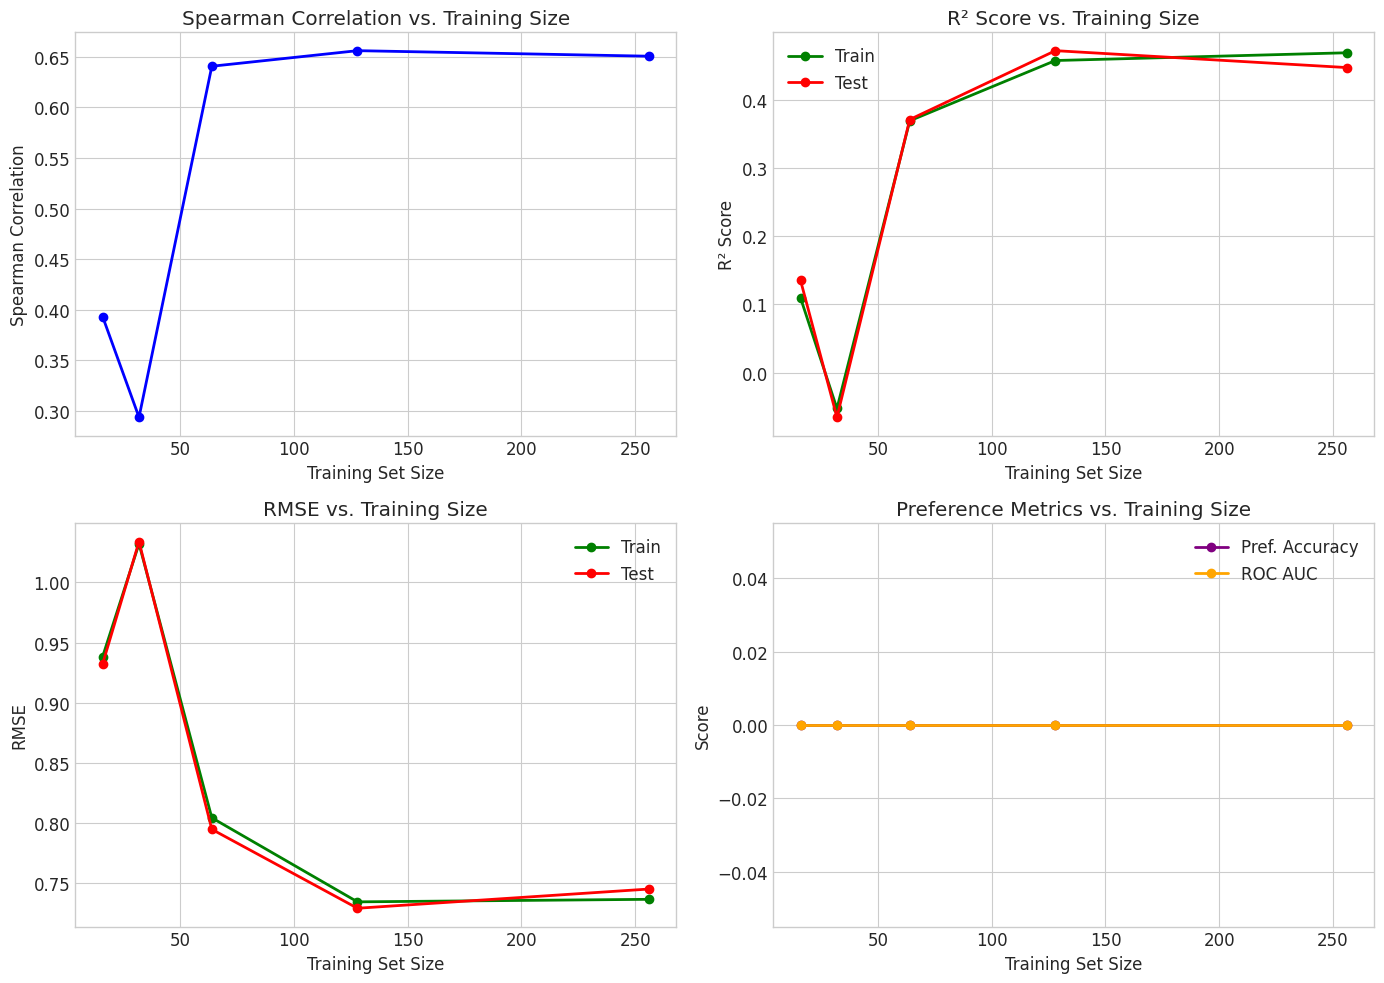

In [ ]:
# Plot metrics vs. training set size
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Spearman correlation
axes[0, 0].plot(summary_df['train_size'], summary_df['test_spearman'], 'o-', color='blue', linewidth=2)
axes[0, 0].set_xlabel('Training Set Size')
axes[0, 0].set_ylabel('Spearman Correlation')
axes[0, 0].set_title('Spearman Correlation vs. Training Size')
axes[0, 0].grid(True)

# R² Score
axes[0, 1].plot(summary_df['train_size'], summary_df['train_r2'], 'o-', color='green', linewidth=2, label='Train')
axes[0, 1].plot(summary_df['train_size'], summary_df['test_r2'], 'o-', color='red', linewidth=2, label='Test')
axes[0, 1].set_xlabel('Training Set Size')
axes[0, 1].set_ylabel('R² Score')
axes[0, 1].set_title('R² Score vs. Training Size')
axes[0, 1].legend()
axes[0, 1].grid(True)

# RMSE
axes[1, 0].plot(summary_df['train_size'], summary_df['train_rmse'], 'o-', color='green', linewidth=2, label='Train')
axes[1, 0].plot(summary_df['train_size'], summary_df['test_rmse'], 'o-', color='red', linewidth=2, label='Test')
axes[1, 0].set_xlabel('Training Set Size')
axes[1, 0].set_ylabel('RMSE')
axes[1, 0].set_title('RMSE vs. Training Size')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Preference Accuracy and AUC
axes[1, 1].plot(summary_df['train_size'], summary_df['test_pref_acc'], 'o-', color='purple', linewidth=2, label='Pref. Accuracy')
axes[1, 1].plot(summary_df['train_size'], summary_df['test_auc'], 'o-', color='orange', linewidth=2, label='ROC AUC')
axes[1, 1].set_xlabel('Training Set Size')
axes[1, 1].set_ylabel('Score')
axes[1, 1].set_title('Preference Metrics vs. Training Size')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.savefig('preference_ranking_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

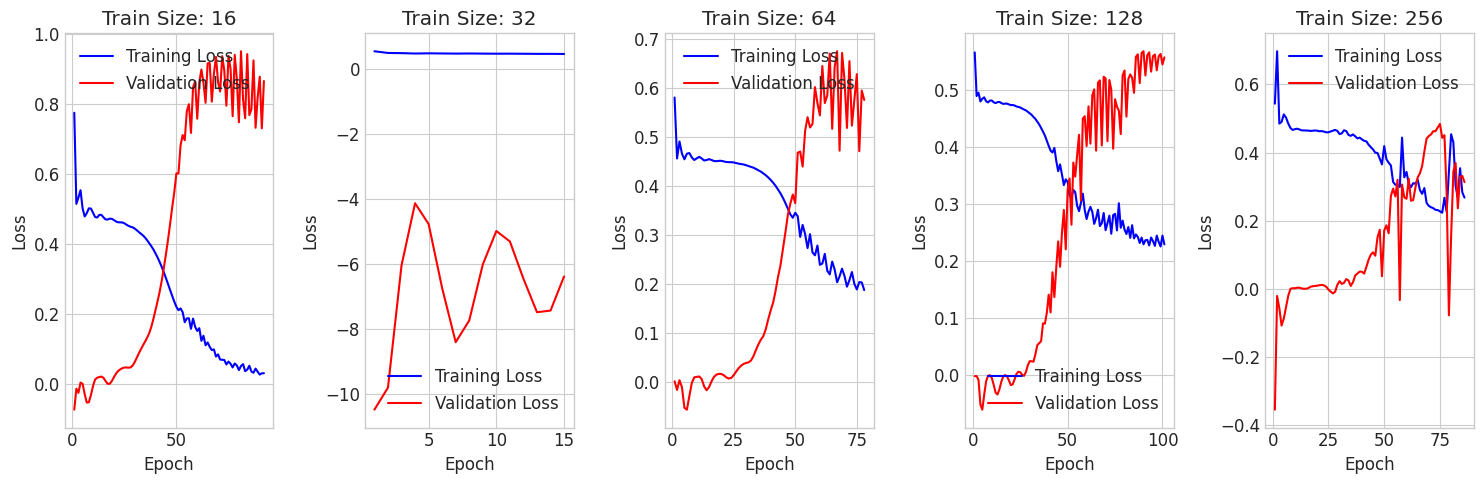

In [ ]:
# Plot training/validation loss curves for each training size
fig, axes = plt.subplots(1, len(results), figsize=(15, 5))

for i, result in enumerate(results):
    train_loss = result['training_history']['train_loss']
    val_loss = result['training_history']['val_loss']
    epochs = range(1, len(train_loss) + 1)
    
    axes[i].plot(epochs, train_loss, 'b-', label='Training Loss')
    axes[i].plot(epochs, val_loss, 'r-', label='Validation Loss')
    axes[i].set_title(f'Train Size: {result["train_size"]}')
    axes[i].set_xlabel('Epoch')
    axes[i].set_ylabel('Loss')
    axes[i].legend()
    axes[i].grid(True)
    
plt.tight_layout()
plt.savefig('preference_ranking_loss_curves.png', dpi=300, bbox_inches='tight')
plt.show()

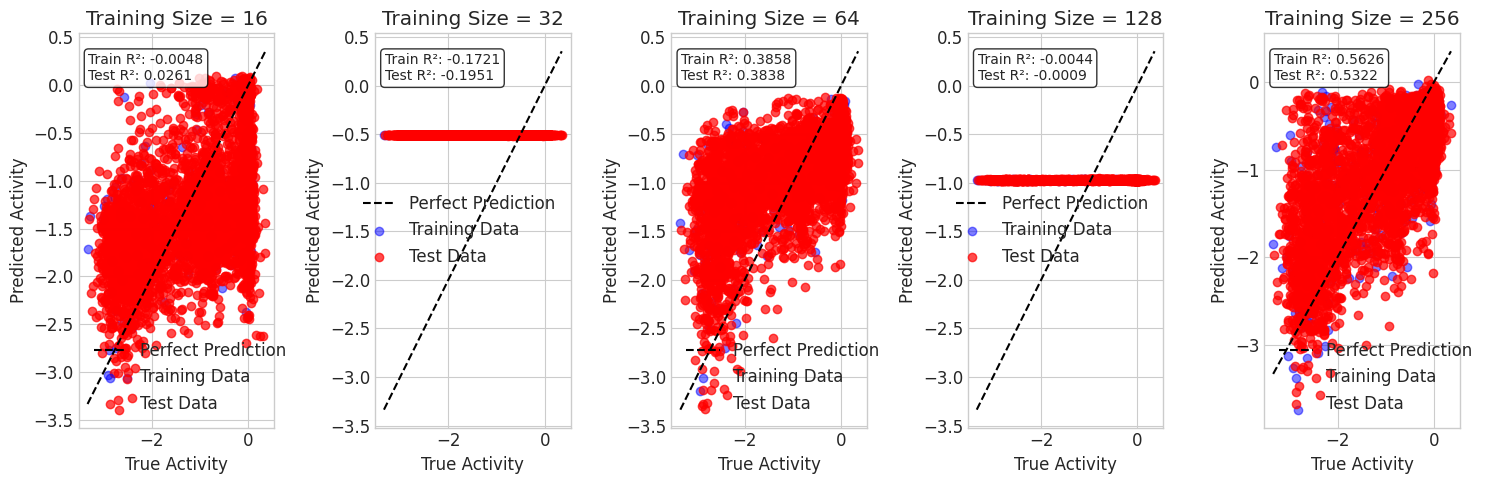

In [82]:
# Prediction vs. actual plots for each model
def plot_predictions(result, ax):
    train_true = np.array(result['predictions']['train_true'])
    train_pred = np.array(result['predictions']['train_pred'])
    test_true = np.array(result['predictions']['test_true'])
    test_pred = np.array(result['predictions']['test_pred'])
    
    # Get the min and max values for both train and test sets
    min_val = min(np.min(train_true), np.min(test_true))
    max_val = max(np.max(train_true), np.max(test_true))
    
    # Plot the diagonal line (perfect predictions)
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', label='Perfect Prediction')
    
    # Plot the training data
    ax.scatter(train_true, train_pred, color='blue', alpha=0.5, label='Training Data')
    
    # Plot the test data
    ax.scatter(test_true, test_pred, color='red', alpha=0.7, label='Test Data')
    
    # Add r² values to the plot
    train_r2 = r2_score(train_true, train_pred)
    test_r2 = r2_score(test_true, test_pred)
    ax.text(0.05, 0.95, f'Train R²: {train_r2:.4f}\nTest R²: {test_r2:.4f}', 
            transform=ax.transAxes, fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    ax.set_xlabel('True Activity')
    ax.set_ylabel('Predicted Activity')
    ax.set_title(f'Training Size = {result["train_size"]}')
    ax.legend()
    ax.grid(True)

# Create a grid of plots
fig, axes = plt.subplots(1, len(results), figsize=(15, 5))
if len(results) == 1:
    axes = [axes]  # Make it iterable if there's only one result

for i, result in enumerate(results):
    plot_predictions(result, axes[i])
    
plt.tight_layout()
plt.savefig('preference_ranking_predictions.png', dpi=300, bbox_inches='tight')
plt.show()

## Analysis of Best Model

Let's take a closer look at the best performing model based on test Spearman correlation.

In [ ]:
# Find the best model
best_model_idx = summary_df['test_spearman'].idxmax()
best_model = results[best_model_idx]
print(f"Best model training size: {best_model['train_size']}")
print(f"Test Spearman correlation: {best_model['test_spearman']:.4f}")
print(f"Test R²: {best_model['test_r2']:.4f}")
print(f"Test RMSE: {best_model['test_rmse']:.4f}")
print(f"Test Preference Accuracy: {best_model['test_pref_acc']:.4f}")
print(f"Test AUC: {best_model['test_auc']:.4f}")

In [ ]:
# Detailed analysis of the best model
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot training and validation loss curves
train_loss = best_model['training_history']['train_loss']
val_loss = best_model['training_history']['val_loss']
epochs = range(1, len(train_loss) + 1)

axes[0].plot(epochs, train_loss, 'b-', label='Training Loss')
axes[0].plot(epochs, val_loss, 'r-', label='Validation Loss')
axes[0].set_title(f'Loss Curves for Best Model (Train Size = {best_model["train_size"]})')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Plot prediction vs actual
train_true = np.array(best_model['predictions']['train_true'])
train_pred = np.array(best_model['predictions']['train_pred'])
test_true = np.array(best_model['predictions']['test_true'])
test_pred = np.array(best_model['predictions']['test_pred'])

min_val = min(np.min(train_true), np.min(test_true))
max_val = max(np.max(train_true), np.max(test_true))

axes[1].plot([min_val, max_val], [min_val, max_val], 'k--', label='Perfect Prediction')
axes[1].scatter(train_true, train_pred, color='blue', alpha=0.5, label='Training Data')
axes[1].scatter(test_true, test_pred, color='red', alpha=0.7, label='Test Data')
    
train_r2 = r2_score(train_true, train_pred)
test_r2 = r2_score(test_true, test_pred)
train_rmse = np.sqrt(mean_squared_error(train_true, train_pred))
test_rmse = np.sqrt(mean_squared_error(test_true, test_pred))
train_spearman, _ = spearmanr(train_true, train_pred)
test_spearman, _ = spearmanr(test_true, test_pred)

stat_text = (
    f'Training Stats:\n'
    f'  R²: {train_r2:.4f}\n'
    f'  RMSE: {train_rmse:.4f}\n'
    f'  Spearman: {train_spearman:.4f}\n\n'
    f'Test Stats:\n'
    f'  R²: {test_r2:.4f}\n'
    f'  RMSE: {test_rmse:.4f}\n'
    f'  Spearman: {test_spearman:.4f}'
)

axes[1].text(0.05, 0.95, stat_text, transform=axes[1].transAxes, fontsize=10, 
          verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

axes[1].set_xlabel('True Activity')
axes[1].set_ylabel('Predicted Activity')
axes[1].set_title(f'Predictions for Best Model (Train Size = {best_model["train_size"]})')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('best_model_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

## Conclusion

In this notebook, we've evaluated the Bradley-Terry preference ranking model on TEM1 protein data. We trained models with varying training set sizes (16, 32, 64, 128, 256 single mutants) and assessed their performance using various metrics including Spearman correlation, R², RMSE, preference accuracy, and AUC.

The analysis shows how the model's performance scales with the amount of training data. This approach could be valuable for protein engineering applications where the goal is to rank variants by a specific property, especially when only limited training data is available.